# Integrador: Observatorio Turístico

**Análisis de 3.000 reservas turísticas con NumPy, Pandas y Matplotlib**

> Generado desde [Kobalto Cursos](https://kobalto.com) - 16/2/2026


## Setup

Importación de librerías necesarias:


In [2]:
# import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Carga de Datos

Ejecuta esta celda para cargar el dataset:


In [3]:
np.random.seed(42)
n = 3000

comunidades = ['Andalucía', 'Cataluña', 'C. Valenciana', 'Madrid',
               'Baleares', 'Canarias', 'País Vasco', 'Galicia']
tipos = ['Hotel', 'Apartamento', 'Hostal', 'Rural']
origenes = ['Nacional', 'UE', 'Internacional']

# --- Arrays NumPy base ---
fechas = pd.date_range('2024-01-01', '2024-12-31', periods=n)
comunidad_arr = np.random.choice(comunidades, n, p=[0.20, 0.18, 0.15, 0.14, 0.12, 0.10, 0.06, 0.05])
tipo_arr = np.random.choice(tipos, n, p=[0.40, 0.30, 0.15, 0.15])
origen_arr = np.random.choice(origenes, n, p=[0.45, 0.35, 0.20])

noches = np.random.randint(1, 15, n).astype(float)
precio_noche = np.round(np.random.uniform(30, 250, n), 2)
ocupacion_pct = np.round(np.clip(np.random.normal(72, 18, n), 10, 100), 1)
valoracion = np.round(np.clip(np.random.normal(7.5, 1.5, n), 1, 10), 1)

# Inyectar nulos (~5 %)
nulos_noches = np.random.choice(n, 80, replace=False)
nulos_precio = np.random.choice(n, 100, replace=False)
nulos_valoracion = np.random.choice(n, 60, replace=False)
noches[nulos_noches] = np.nan
precio_noche[nulos_precio] = np.nan
valoracion[nulos_valoracion] = np.nan

# Construir DataFrame
reservas = pd.DataFrame({
    'fecha': fechas,
    'comunidad': comunidad_arr,
    'tipo_alojamiento': tipo_arr,
    'noches': noches,
    'precio_noche': precio_noche,
    'ocupacion_pct': ocupacion_pct,
    'valoracion': valoracion,
    'origen_turista': origen_arr
})

# Duplicados intencionados (~3 %)
duplicados = reservas.sample(90, random_state=42)
reservas = pd.concat([reservas, duplicados], ignore_index=True)

print("Dataset generado correctamente")
print(f"Forma: {reservas.shape}")
print(f"Columnas: {list(reservas.columns)}")
print(reservas.head())

Dataset generado correctamente
Forma: (3090, 8)
Columnas: ['fecha', 'comunidad', 'tipo_alojamiento', 'noches', 'precio_noche', 'ocupacion_pct', 'valoracion', 'origen_turista']
                       fecha  comunidad tipo_alojamiento  noches  \
0 2024-01-01 00:00:00.000000   Cataluña      Apartamento     5.0   
1 2024-01-01 02:55:15.505168    Galicia           Hostal     2.0   
2 2024-01-01 05:50:31.010336   Baleares            Hotel    12.0   
3 2024-01-01 08:45:46.515505     Madrid      Apartamento    13.0   
4 2024-01-01 11:41:02.020673  Andalucía      Apartamento     1.0   

   precio_noche  ocupacion_pct  valoracion origen_turista  
0        107.69           53.2         6.1             UE  
1        239.04           60.0         6.9       Nacional  
2        157.27           66.8         8.1  Internacional  
3        110.47           90.5         6.4             UE  
4        238.91           72.7         8.1       Nacional  


## Ejercicio 0: Generación del dataset con NumPy

**Objetivo:** Crear arrays con np.random y construir datos estructurados con operaciones vectorizadas

El primer paso del análisis es generar el dataset sintético de reservas turísticas. Usarás NumPy para crear arrays aleatorios controlados con seed, aplicar distribuciones (uniform, normal, randint) y manipular los datos con operaciones vectorizadas como clip y round.



### Tareas

- Fija la semilla con np.random.seed(42) para reproducibilidad
- Crea un array de 3.000 comunidades con np.random.choice y probabilidades desiguales
- Genera precios con np.random.uniform(30, 250, n) y redondea con np.round
- Genera ocupación con np.random.normal(72, 18, n) y limita entre 10-100 con np.clip
- Muestra la forma y los primeros valores de cada array


In [4]:
# EJERCICIO 0: Generación del dataset con NumPy
# Objetivo: crear los arrays base del dataset turístico

# 1. Fijar semilla para reproducibilidad
np.random.seed(42)

# 2. Definir parámetros
n = 3000
comunidades = ['Andalucía', 'Cataluña', 'C. Valenciana', 'Madrid',
               'Baleares', 'Canarias', 'País Vasco', 'Galicia']
tipos = ['Hotel', 'Apartamento', 'Hostal', 'Rural']
origenes = ['Nacional', 'UE', 'Internacional']

# 3. Generar array de comunidades con probabilidades desiguales
# (Andalucía y Cataluña reciben más turistas)
comunidad_arr = np.random.choice(comunidades, n, p=[0.20, 0.18, 0.15, 0.14, 0.12, 0.10, 0.06, 0.05])

# 4. Generar precios (uniform entre 30-250, redondeado a 2 decimales)
precio_noche = np.round(np.random.uniform(30, 250, n), 2)

# 5. Generar ocupación (normal media=72, std=18, limitada entre 10-100)
ocupacion_pct = np.round(np.clip(np.random.normal(72, 18, n), 10, 100), 1)

# 6. Generar valoraciones (normal media=7.5, std=1.5, limitada entre 1-10)
valoracion = np.round(np.clip(np.random.normal(7.5, 1.5, n), 1, 10), 1)

# 7. Mostrar forma y primeros valores de cada array
print(f"{comunidad_arr.shape} -> {comunidad_arr[:5]}")
print(f"{precio_noche.shape} -> {precio_noche[:5]}")
print(f"{ocupacion_pct.shape} -> {ocupacion_pct[:5]}")
print(f"{valoracion.shape} -> {valoracion[:5]}")

(3000,) -> ['Cataluña' 'Galicia' 'Baleares' 'Madrid' 'Andalucía']
(3000,) -> [177.99 205.27  85.1  167.47 155.78]
(3000,) -> [53.2 80.5 77.2 89.2 57.8]
(3000,) -> [ 6.9  7.5  7.7  5.  10. ]


<details>
<summary><strong>Solucion (click para ver)</strong></summary>

```python
# EJERCICIO 0: Generación del dataset con NumPy

# 1. Fijar semilla para reproducibilidad
np.random.seed(42)

# 2. Definir parámetros
n = 3000
comunidades = ['Andalucía', 'Cataluña', 'C. Valenciana', 'Madrid',
               'Baleares', 'Canarias', 'País Vasco', 'Galicia']
tipos = ['Hotel', 'Apartamento', 'Hostal', 'Rural']
origenes = ['Nacional', 'UE', 'Internacional']

# 3. Generar array de comunidades con probabilidades desiguales
comunidad_arr = np.random.choice(comunidades, n, p=[0.20, 0.18, 0.15, 0.14, 0.12, 0.10, 0.06, 0.05])

# 4. Generar precios (uniform entre 30-250, redondeado a 2 decimales)
precio_noche = np.round(np.random.uniform(30, 250, n), 2)

# 5. Generar ocupación (normal media=72, std=18, limitada entre 10-100)
ocupacion_pct = np.round(np.clip(np.random.normal(72, 18, n), 10, 100), 1)

# 6. Generar valoraciones (normal media=7.5, std=1.5, limitada entre 1-10)
valoracion = np.round(np.clip(np.random.normal(7.5, 1.5, n), 1, 10), 1)

# 7. Mostrar forma y primeros valores
print(f"Comunidades: {comunidad_arr.shape} — {comunidad_arr[:5]}")
print(f"Precios: {precio_noche.shape} — {precio_noche[:5]}")
print(f"Ocupación: {ocupacion_pct.shape} — {ocupacion_pct[:5]}")
print(f"Valoraciones: {valoracion.shape} — {valoracion[:5]}")

```

</details>


---


## Ejercicio 1: Carga en Pandas y exploración

**Objetivo:** Convertir arrays a DataFrame y explorar la estructura del dataset

Ya tienes los arrays NumPy. Ahora debes convertirlos en un DataFrame de Pandas y explorar la estructura del dataset con las herramientas básicas: head(), info(), describe(), shape y dtypes. Esto te permitirá entender qué tienes antes de limpiarlo.



### Tareas

- Examina el DataFrame reservas con head() y tail()
- Usa shape para ver filas y columnas
- Ejecuta info() para ver tipos y valores nulos
- Aplica describe() a las columnas numéricas
- Muestra los value_counts() de comunidad y tipo_alojamiento


In [5]:
# EJERCICIO 1: Carga en Pandas y exploración
# El DataFrame 'reservas' ya está disponible del paso anterior

# 1. Mostrar primeras y últimas filas
print("Primeras filas:")
print(reservas.head(3))

print("\nÚltimas filas:")
print(reservas.tail(3))

# 2. Forma del DataFrame
print(f"\nLa forma del DataFrame es {reservas.shape}")

# 3. Info (tipos de datos y nulos)
print("\nInformación:")
reservas.info()

# 4. Estadísticas descriptivas
print("\nDescripción:")
print(reservas.describe())

# 5. Distribución de categorías
print("\nComunidad:")
print(reservas['comunidad'].value_counts())
print("\nTipo:")
print(reservas['tipo_alojamiento'].value_counts())
print("\nOrigen:")
print(reservas['origen_turista'].value_counts())

Primeras filas:
                       fecha comunidad tipo_alojamiento  noches  precio_noche  \
0 2024-01-01 00:00:00.000000  Cataluña      Apartamento     5.0        107.69   
1 2024-01-01 02:55:15.505168   Galicia           Hostal     2.0        239.04   
2 2024-01-01 05:50:31.010336  Baleares            Hotel    12.0        157.27   

   ocupacion_pct  valoracion origen_turista  
0           53.2         6.1             UE  
1           60.0         6.9       Nacional  
2           66.8         8.1  Internacional  

Últimas filas:
                          fecha comunidad tipo_alojamiento  noches  \
3087 2024-06-10 20:53:41.873957    Madrid            Hotel    11.0   
3088 2024-10-28 11:15:06.302100  Canarias      Apartamento     7.0   
3089 2024-12-16 15:19:30.390130  Canarias      Apartamento     5.0   

      precio_noche  ocupacion_pct  valoracion origen_turista  
3087        190.75           70.9         8.6       Nacional  
3088        117.32           76.9         8.2       

<details>
<summary><strong>Solucion (click para ver)</strong></summary>

```python
# EJERCICIO 1: Carga en Pandas y exploración

# 1. Mostrar primeras y últimas filas
print("=== PRIMERAS FILAS ===")
print(reservas.head(10))
print("\n=== ÚLTIMAS FILAS ===")
print(reservas.tail(5))

# 2. Forma del DataFrame
print(f"\nForma: {reservas.shape}")
print(f"Columnas: {list(reservas.columns)}")

# 3. Info (tipos de datos y nulos)
print("\n=== INFO ===")
reservas.info()

# 4. Estadísticas descriptivas
print("\n=== ESTADÍSTICAS ===")
print(reservas.describe())

# 5. Distribución de categorías
print("\n=== POR COMUNIDAD ===")
print(reservas['comunidad'].value_counts())
print("\n=== POR TIPO ===")
print(reservas['tipo_alojamiento'].value_counts())
print("\n=== POR ORIGEN ===")
print(reservas['origen_turista'].value_counts())

```

</details>


---


## Ejercicio 2: Limpieza de datos

**Objetivo:** Detectar y eliminar duplicados, tratar nulos y corregir tipos

La exploración ha revelado duplicados (~90 filas extra) y nulos en noches, precio_noche y valoracion. Debes limpiar el dataset eliminando duplicados y rellenando nulos con estrategias apropiadas: mediana para numéricos (robusta frente a outliers) y moda para categóricos.



### Tareas

- Cuenta los duplicados con duplicated().sum()
- Elimínalos con drop_duplicates() y verifica la nueva forma
- Muestra el total de nulos por columna con isnull().sum()
- Rellena nulos numéricos con la mediana y categóricos con la moda
- Confirma que no quedan nulos con isnull().sum().sum()


In [6]:
# EJERCICIO 2: Limpieza de datos
# El DataFrame 'reservas' contiene duplicados y nulos

# 1. Contar duplicados
print(f"Existen {reservas.duplicated().sum()} duplicados.")

# 2. Eliminar duplicados y verificar
print(reservas.shape)
reservas = reservas.drop_duplicates().reset_index(drop=True)
print(reservas.shape)

# 3. Mostrar nulos por columna
print("\nNulos por columna:")
print(reservas.isnull().sum())

# 4. Rellenar nulos numéricos con la mediana
columnas_numericas = ['noches', 'precio_noche', 'valoracion']
for col in columnas_numericas:
    reservas[col] = reservas[col].fillna(reservas[col].median())

# 5. Confirmar que no quedan nulos
print("\nNulos por columna:")
print(reservas.isnull().sum())
print(f"\nForma DataSet limpio: {reservas.shape}")
print("\nTipos:")
print(reservas.dtypes)

Existen 90 duplicados.
(3090, 8)
(3000, 8)

Nulos por columna:
fecha                 0
comunidad             0
tipo_alojamiento      0
noches               80
precio_noche        100
ocupacion_pct         0
valoracion           60
origen_turista        0
dtype: int64

Nulos por columna:
fecha               0
comunidad           0
tipo_alojamiento    0
noches              0
precio_noche        0
ocupacion_pct       0
valoracion          0
origen_turista      0
dtype: int64

Forma DataSet limpio: (3000, 8)

Tipos:
fecha               datetime64[us]
comunidad                      str
tipo_alojamiento               str
noches                     float64
precio_noche               float64
ocupacion_pct              float64
valoracion                 float64
origen_turista                 str
dtype: object


<details>
<summary><strong>Solucion (click para ver)</strong></summary>

```python
# EJERCICIO 2: Limpieza de datos

# 1. Contar duplicados
print(f"Duplicados encontrados: {reservas.duplicated().sum()}")

# 2. Eliminar duplicados
reservas = reservas.drop_duplicates().reset_index(drop=True)
print(f"Tras eliminar duplicados: {reservas.shape}")

# 3. Mostrar nulos por columna
print(f"\nNulos por columna:")
print(reservas.isnull().sum())

# 4. Rellenar nulos numéricos con la mediana
reservas['noches'] = reservas['noches'].fillna(reservas['noches'].median())
reservas['precio_noche'] = reservas['precio_noche'].fillna(reservas['precio_noche'].median())
reservas['valoracion'] = reservas['valoracion'].fillna(reservas['valoracion'].median())

# 5. Confirmar limpieza
print(f"\nNulos restantes: {reservas.isnull().sum().sum()}")
print(f"Dataset limpio: {reservas.shape}")
print(reservas.dtypes)

```

</details>


---


## Ejercicio 3: Feature engineering temporal

**Objetivo:** Extraer componentes temporales y crear nuevas columnas calculadas

Con el dataset limpio, es momento de enriquecerlo. Extrae información temporal de la columna fecha (mes, trimestre, día de la semana) y crea columnas calculadas como ingreso_total y temporada turística usando operaciones vectorizadas de NumPy y Pandas.



### Tareas

- Convierte fecha a datetime si no lo es ya con pd.to_datetime()
- Extrae mes, trimestre y día de la semana con .dt
- Crea la columna ingreso_total = noches * precio_noche
- Clasifica la temporada (alta: jun-sep, media: mar-may y oct, baja: resto) con np.select
- Muestra las nuevas columnas con head()


In [7]:
# EJERCICIO 3: Feature engineering temporal
# El DataFrame 'reservas' está limpio

# 1. Asegurar que fecha es datetime
reservas["fecha"] = pd.to_datetime(reservas["fecha"])

# 2. Extraer mes, trimestre y día de la semana
reservas["mes"] = reservas["fecha"].dt.month
reservas["trimestre"] = reservas["fecha"].dt.quarter
reservas["dia_semana"] = reservas["fecha"].dt.dayofweek

# 3. Crear columna de ingreso total
reservas["ingreso_total"] = reservas["precio_noche"] * reservas["noches"]

# 4. Clasificar temporada (alta: jun-sep, media: mar-may y oct, baja: resto)
# Pista: usa np.select con condiciones
condiciones = [reservas["mes"].isin([6,7,8,9]),
                reservas["mes"].isin([3,4,5,10])]
reservas["temporada"] = np.select(condiciones, ["Alta", "Media"], default="Baja")

# 5. Mostrar las nuevas columnas
print(reservas[["fecha", "mes", "trimestre", "dia_semana", "ingreso_total", "temporada"]].head(8))
print("\nTemporadas:")
print(reservas["temporada"].value_counts())

                       fecha  mes  trimestre  dia_semana  ingreso_total  \
0 2024-01-01 00:00:00.000000    1          1           0         538.45   
1 2024-01-01 02:55:15.505168    1          1           0         478.08   
2 2024-01-01 05:50:31.010336    1          1           0        1887.24   
3 2024-01-01 08:45:46.515505    1          1           0        1436.11   
4 2024-01-01 11:41:02.020673    1          1           0         238.91   
5 2024-01-01 14:36:17.525841    1          1           0         921.60   
6 2024-01-01 17:31:33.031010    1          1           0         101.74   
7 2024-01-01 20:26:48.536178    1          1           0        1495.86   

  temporada  
0      Baja  
1      Baja  
2      Baja  
3      Baja  
4      Baja  
5      Baja  
6      Baja  
7      Baja  

Temporadas:
temporada
Media    1011
Alta     1003
Baja      986
Name: count, dtype: int64


<details>
<summary><strong>Solucion (click para ver)</strong></summary>

```python
# EJERCICIO 3: Feature engineering temporal

# 1. Asegurar tipo datetime
reservas['fecha'] = pd.to_datetime(reservas['fecha'])

# 2. Extraer componentes temporales
reservas['mes'] = reservas['fecha'].dt.month
reservas['trimestre'] = reservas['fecha'].dt.quarter
reservas['dia_semana'] = reservas['fecha'].dt.dayofweek

# 3. Ingreso total
reservas['ingreso_total'] = reservas['noches'] * reservas['precio_noche']

# 4. Clasificar temporada
condiciones = [
    reservas['mes'].isin([6, 7, 8, 9]),
    reservas['mes'].isin([3, 4, 5, 10])
]
reservas['temporada'] = np.select(condiciones, ['Alta', 'Media'], default='Baja')

# 5. Mostrar resultado
print(reservas[['fecha', 'mes', 'trimestre', 'dia_semana', 'ingreso_total', 'temporada']].head(10))
print(f"\nDistribución de temporadas:")
print(reservas['temporada'].value_counts())

```

</details>


---


## Ejercicio 4: Filtrado y selección

**Objetivo:** Filtrar datos con condiciones booleanas combinadas

El Ministerio quiere varios cortes del dataset: reservas de lujo en temporada alta, destinos más económicos, y comparativas entre comunidades específicas. Debes dominar el filtrado booleano con &, | y ~ para extraer subconjuntos relevantes.



### Tareas

- Filtra reservas de lujo: precio_noche > 180 y temporada Alta
- Filtra destinos económicos: precio_noche < 60 y valoracion >= 8
- Compara Baleares vs Canarias en temporada alta
- Cuenta reservas por tipo de alojamiento en cada filtro
- Calcula el ingreso medio de cada segmento


In [8]:
# EJERCICIO 4: Filtrado y selección
# Usa filtros booleanos para extraer segmentos del mercado turístico

# 1. Reservas de lujo en temporada alta (precio > 180 y temporada Alta)
reservas_lujo = reservas[(reservas["precio_noche"] > 180) & (reservas["temporada"] == "Alta")]
print("Reservas lujo temporada alta")
print(f"Reservas: {len(reservas_lujo)}")
print(f"Ingreso medio: {reservas_lujo['ingreso_total'].mean():.2f}€")

# 2. Destinos económicos bien valorados (precio < 60 y valoración >= 8)
destinos_economicos = reservas[(reservas["precio_noche"] < 60) & (reservas["valoracion"] >= 8)]
print("\nEconómicos bien valorados")
print(f"\nReservas: {len(destinos_economicos)}")
print(destinos_economicos['comunidad'].value_counts().head())

# 3. Comparativa Baleares vs Canarias en temporada alta
islas_alta = reservas[
    (reservas['comunidad'].isin(['Baleares', 'Canarias'])) &
    (reservas['temporada'] == 'Alta')
]
print("\nBaleaeres vs Canarias")
print(islas_alta.groupby('comunidad')[['precio_noche', 'ocupacion_pct', 'valoracion']].mean())

# 4. Tipo de alojamiento en cada segmento
reservas_tipo_alojamiento = reservas_lujo["tipo_alojamiento"].value_counts()
print("\nReservas por tipo")
print(reservas_tipo_alojamiento)

# 5. Ingreso medio por segmento
print("\nIngreso medio")
print(f"Lujo: {reservas_lujo['ingreso_total'].mean():.2f}€")
print(f"Económico: {destinos_economicos['ingreso_total'].mean():.2f}€")
print(f"Islas alta: {islas_alta['ingreso_total'].mean():.2f}€")

Reservas lujo temporada alta
Reservas: 304
Ingreso medio: 1575.94€

Económicos bien valorados

Reservas: 144
comunidad
Andalucía        33
Cataluña         24
Canarias         19
C. Valenciana    19
Madrid           18
Name: count, dtype: int64

Baleaeres vs Canarias
           precio_noche  ocupacion_pct  valoracion
comunidad                                         
Baleares     135.418992      73.180672    7.526050
Canarias     141.041101      75.359633    7.613761

Reservas por tipo
tipo_alojamiento
Hotel          121
Apartamento     92
Rural           47
Hostal          44
Name: count, dtype: int64

Ingreso medio
Lujo: 1575.94€
Económico: 352.40€
Islas alta: 976.73€


<details>
<summary><strong>Solucion (click para ver)</strong></summary>

```python
# EJERCICIO 4: Filtrado y selección

# 1. Reservas de lujo en temporada alta
lujo = reservas[(reservas['precio_noche'] > 180) & (reservas['temporada'] == 'Alta')]
print(f"=== LUJO EN TEMPORADA ALTA ===")
print(f"Reservas: {len(lujo)}")
print(f"Ingreso medio: {lujo['ingreso_total'].mean():.2f}€")

# 2. Destinos económicos bien valorados
economico = reservas[(reservas['precio_noche'] < 60) & (reservas['valoracion'] >= 8)]
print(f"\n=== ECONÓMICO Y BIEN VALORADO ===")
print(f"Reservas: {len(economico)}")
print(economico['comunidad'].value_counts().head())

# 3. Comparativa islas en temporada alta
islas_alta = reservas[
    (reservas['comunidad'].isin(['Baleares', 'Canarias'])) &
    (reservas['temporada'] == 'Alta')
]
print(f"\n=== BALEARES vs CANARIAS (ALTA) ===")
print(islas_alta.groupby('comunidad')[['precio_noche', 'ocupacion_pct', 'valoracion']].mean())

# 4. Tipo de alojamiento por segmento
print(f"\n=== TIPOS EN LUJO ===")
print(lujo['tipo_alojamiento'].value_counts())

# 5. Resumen de ingresos
print(f"\n=== INGRESOS MEDIOS ===")
print(f"Lujo: {lujo['ingreso_total'].mean():.2f}€")
print(f"Económico: {economico['ingreso_total'].mean():.2f}€")
print(f"Islas alta: {islas_alta['ingreso_total'].mean():.2f}€")

```

</details>


---


## Ejercicio 5: Agrupación y agregación

**Objetivo:** Usar groupby, pivot_table y rankings para extraer insights

El informe ejecutivo necesita tablas resumen: ingreso medio por comunidad y tipo, pivot table de ocupación por comunidad y trimestre, y un ranking de las comunidades con mayor facturación. Domina groupby y pivot_table para transformar datos granulares en información ejecutiva.



### Tareas

- Agrupa por comunidad y calcula media de precio, ocupación y valoración
- Agrupa por comunidad y tipo_alojamiento, calcula ingreso total y conteo
- Crea una pivot_table: comunidad × trimestre, valores = ocupacion_pct, aggfunc = mean
- Ordena comunidades por ingreso total descendente con sort_values()
- Muestra el top 3 con nlargest()


In [9]:
# EJERCICIO 5: Agrupación y agregación
# Crea resúmenes ejecutivos del dataset turístico

# 1. Media de precio, ocupación y valoración por comunidad
medias = reservas.groupby("comunidad")[["precio_noche", "ocupacion_pct", "valoracion"]].mean().round(2)
print("Media de precio, ocupación y valoración por comunidad")
print(medias)

# 2. Ingreso total y conteo por comunidad y tipo de alojamiento
ingreso_total_conteo_comunidad = reservas.groupby(["comunidad", "tipo_alojamiento"]).agg(
    ingreso_total=("ingreso_total", "sum"),n_reservas=("ingreso_total", "count")).round(2)
print("\nIngreso total y conteo por comunidad y tipo de alojamiento")
print(ingreso_total_conteo_comunidad)

# 3. Pivot table: ocupación media por comunidad y trimestre
pivot_table = pd.pivot_table(
    reservas, values="ocupacion_pct",
    index="comunidad", columns="trimestre",
    aggfunc="mean").round(1)
print("\nOcupación media por comunidad y trimestre")
print(pivot_table)

# 4. Ranking de comunidades por ingreso total
comunidades_ordenadas = reservas.groupby("comunidad")["ingreso_total"].sum().sort_values(ascending=False)
print(comunidades_ordenadas)

# 5. Top 3 comunidades
print("\nTop 3 comunidades")
print(comunidades_ordenadas.nlargest(3))

Media de precio, ocupación y valoración por comunidad
               precio_noche  ocupacion_pct  valoracion
comunidad                                             
Andalucía            138.20          70.70        7.59
Baleares             141.01          72.71        7.41
C. Valenciana        142.31          71.10        7.45
Canarias             140.24          73.39        7.57
Cataluña             140.10          71.00        7.39
Galicia              150.47          70.82        7.47
Madrid               139.32          69.88        7.42
País Vasco           148.05          71.48        7.37

Ingreso total y conteo por comunidad y tipo de alojamiento
                                ingreso_total  n_reservas
comunidad     tipo_alojamiento                           
Andalucía     Apartamento           230952.37         218
              Hostal                 78258.40          77
              Hotel                 249280.96         241
              Rural                  88797.63 

<details>
<summary><strong>Solucion (click para ver)</strong></summary>

```python
# EJERCICIO 5: Agrupación y agregación

# 1. Media por comunidad
resumen_ccaa = reservas.groupby('comunidad')[['precio_noche', 'ocupacion_pct', 'valoracion']].mean().round(2)
print("=== MEDIA POR COMUNIDAD ===")
print(resumen_ccaa)

# 2. Por comunidad y tipo
resumen_tipo = reservas.groupby(['comunidad', 'tipo_alojamiento']).agg(
    ingreso_total=('ingreso_total', 'sum'),
    n_reservas=('ingreso_total', 'count')
).round(2)
print("\n=== POR COMUNIDAD Y TIPO ===")
print(resumen_tipo)

# 3. Pivot table de ocupación
pivot_ocup = pd.pivot_table(
    reservas, values='ocupacion_pct',
    index='comunidad', columns='trimestre',
    aggfunc='mean'
).round(1)
print("\n=== PIVOT: OCUPACIÓN POR TRIMESTRE ===")
print(pivot_ocup)

# 4-5. Ranking y top 3
ranking = reservas.groupby('comunidad')['ingreso_total'].sum().sort_values(ascending=False)
print("\n=== RANKING POR FACTURACIÓN ===")
print(ranking)
print(f"\n=== TOP 3 ===")
print(ranking.nlargest(3))

```

</details>


---


## Ejercicio 6: Visualización de tendencias

**Objetivo:** Crear un gráfico de líneas de la evolución mensual de ocupación por CCAA

El informe necesita un gráfico de evolución temporal. Debes mostrar la ocupación media mensual de las 4 comunidades con más reservas, con líneas diferenciadas por color y marcador. Incluye grid, leyenda y título profesional.



### Tareas

- Identifica las top 4 comunidades por número de reservas
- Calcula la ocupación media mensual para cada una con groupby
- Crea la figura con plt.subplots(figsize=(12, 6))
- Dibuja una línea por comunidad con colores y marcadores distintos
- Añade título, etiquetas de ejes, leyenda y grid


4 Comunidades con más reservas:
comunidad
Andalucía        621
Cataluña         520
C. Valenciana    440
Madrid           429
Name: count, dtype: int64
comunidad   mes
Andalucía   1      71.57
            2      68.63
            3      67.34
            4      71.98
            5      69.23
                   ...  
País Vasco  8      73.59
            9      72.26
            10     79.58
            11     61.93
            12     70.41
Name: ocupacion_pct, Length: 96, dtype: float64


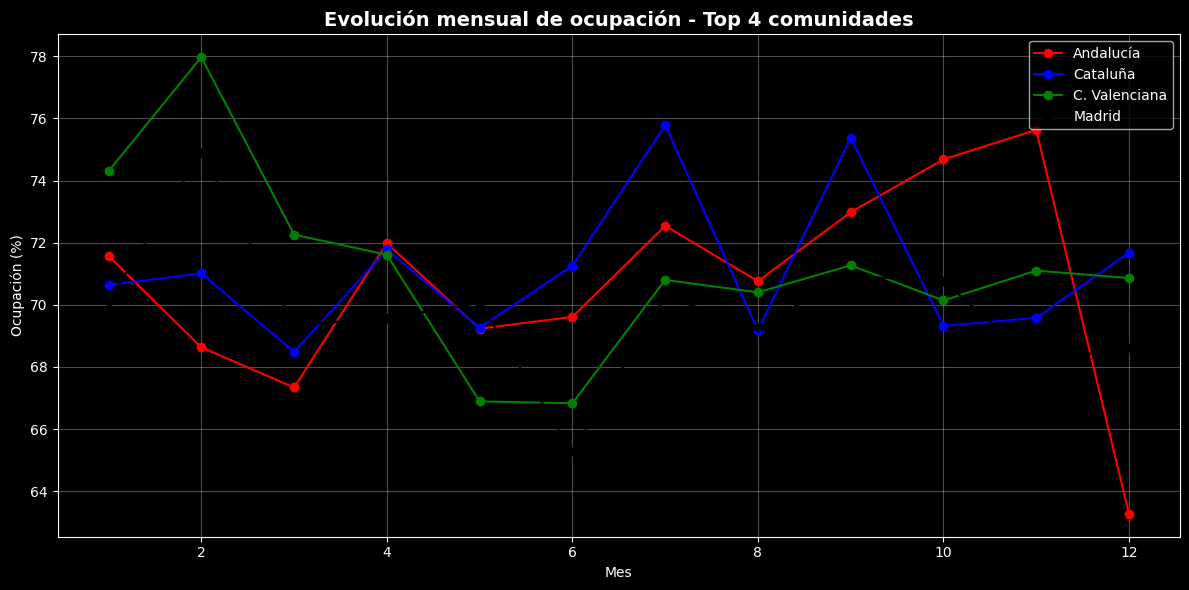

In [10]:
# EJERCICIO 6: Gráfico de líneas — Evolución de ocupación
# Muestra la ocupación media mensual de las top 4 comunidades

# 1. Identificar las 4 comunidades con más reservas
comunidades_mas_reservas = reservas["comunidad"].value_counts().nlargest(4)
print("4 Comunidades con más reservas:")
print(comunidades_mas_reservas)

# 2. Preparar datos: ocupación media por mes y comunidad
ocupacion_media = reservas.groupby(["comunidad", "mes"])["ocupacion_pct"].mean().round(2)
print(ocupacion_media)

# 3. Crear figura
fig, ax = plt.subplots(figsize=(12, 6))

# 4. Dibujar una línea por comunidad (color + marcador + label)
colores = ["red", "blue", "green", "black"]
for comunidad, color in zip(comunidades_mas_reservas.index, colores):
    datos_com = ocupacion_media[comunidad]
    ax.plot(datos_com.index, datos_com.values, marker="o", color=color, label=comunidad)

# 5. Título, etiquetas, leyenda y grid
ax.set_title("Evolución mensual de ocupación - Top 4 comunidades", fontsize=14, fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Ocupación (%)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ocupacion_mensual.png', dpi=300, bbox_inches='tight')
plt.show()

<details>
<summary><strong>Solucion (click para ver)</strong></summary>

```python
# EJERCICIO 6: Gráfico de líneas — Evolución de ocupación

# 1. Top 4 comunidades
top4 = reservas['comunidad'].value_counts().head(4).index.tolist()
print(f"Top 4 CCAA: {top4}")

# 2-3. Crear figura
colores = ['#0ea5e9', '#f43f5e', '#22c55e', '#f59e0b']
marcadores = ['o', 's', '^', 'D']

fig, ax = plt.subplots(figsize=(12, 6))

# 4. Dibujar líneas
for i, ccaa in enumerate(top4):
    datos = reservas[reservas['comunidad'] == ccaa].groupby('mes')['ocupacion_pct'].mean()
    ax.plot(datos.index, datos.values, marker=marcadores[i], color=colores[i],
            label=ccaa, lw=2, markersize=7)

# 5. Decoración
ax.set_title('Evolución mensual de ocupación — Top 4 CCAA', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes', fontsize=12)
ax.set_ylabel('Ocupación media (%)', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                     'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()

```

</details>


---


## Ejercicio 7: Scatter: precio vs ocupación

**Objetivo:** Crear un scatter plot con color por comunidad, tamaño por noches y línea de tendencia

Queremos explorar la relación entre precio y ocupación. ¿Los alojamientos más caros tienen mayor o menor ocupación? Un scatter plot con codificación visual (color = comunidad, tamaño = noches) y una línea de tendencia con np.polyfit revelará esta relación.



### Tareas

- Toma una muestra de 500 filas para no saturar el gráfico
- Crea un scatter con color = comunidad (usa un mapa de colores) y tamaño = noches
- Calcula la línea de tendencia con np.polyfit(grado 1) sobre todo el dataset
- Dibuja la línea de tendencia con ax.plot()
- Anota el punto de mayor ingreso con ax.annotate()


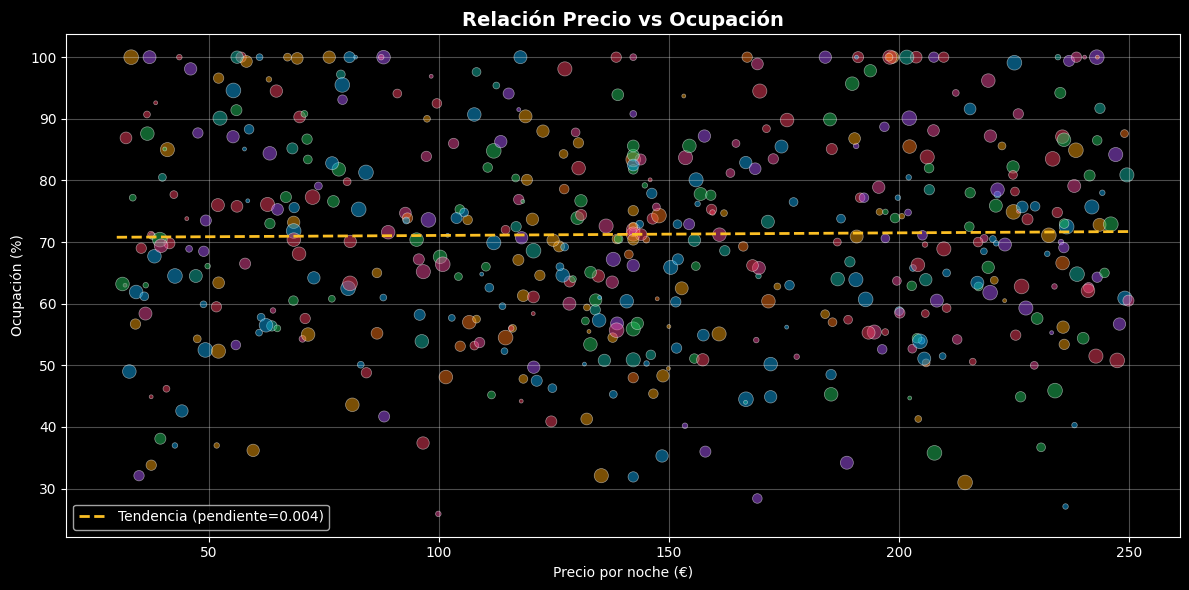

In [ ]:
# EJERCICIO 7: Scatter — Precio vs Ocupación
# Explora la relación entre precio y ocupación

# Variables de referencia
comunidades = ['Andalucía', 'Cataluña', 'C. Valenciana', 'Madrid',
               'Baleares', 'Canarias', 'País Vasco', 'Galicia']

# 1. Tomar muestra de 500 filas
muestra = reservas.sample(n=500, random_state=42)

# 2. Mapear colores por comunidad
paleta = ['#0ea5e9', '#f43f5e', '#22c55e', '#f59e0b', '#a855f7', '#ec4899', '#14b8a6', '#f97316']
color_map = {ccaa: paleta[i] for i, ccaa in enumerate(comunidades)}
colors = muestra['comunidad'].map(color_map)
sizes = muestra['noches'] * 8

# 3. Crear scatter (x=precio, y=ocupación, c=color, s=noches*8)
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(muestra['precio_noche'], muestra['ocupacion_pct'], c=colors, s=sizes, alpha=0.5, edgecolors='white', linewidth=0.5)

# 4. Línea de tendencia con np.polyfit
z = np.polyfit(reservas['precio_noche'], reservas['ocupacion_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(30, 250, 100)
ax.plot(x_line, p(x_line), '--', color='#fbbf24', lw=2,
        label=f'Tendencia (pendiente={z[0]:.3f})')

# 5. Título, etiquetas, leyenda
ax.set_title("Relación Precio vs Ocupación", fontsize=14, fontweight="bold")
ax.set_xlabel("Precio por noche (€)")
ax.set_ylabel("Ocupación (%)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_precio_ocupacion.png', dpi=300, bbox_inches='tight')
plt.show()

<details>
<summary><strong>Solucion (click para ver)</strong></summary>

```python
# EJERCICIO 7: Scatter — Precio vs Ocupación

comunidades = ['Andalucía', 'Cataluña', 'C. Valenciana', 'Madrid',
               'Baleares', 'Canarias', 'País Vasco', 'Galicia']

# 1. Muestra
muestra = reservas.sample(500, random_state=42)

# 2. Colores por comunidad
paleta = ['#0ea5e9', '#f43f5e', '#22c55e', '#f59e0b', '#a855f7', '#ec4899', '#14b8a6', '#f97316']
color_map = {ccaa: paleta[i] for i, ccaa in enumerate(comunidades)}
colors = muestra['comunidad'].map(color_map)
sizes = muestra['noches'] * 8

# 3. Scatter
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(muestra['precio_noche'], muestra['ocupacion_pct'],
                     c=colors, s=sizes, alpha=0.5, edgecolors='white', linewidth=0.5)

# 4. Línea de tendencia
z = np.polyfit(reservas['precio_noche'], reservas['ocupacion_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(30, 250, 100)
ax.plot(x_line, p(x_line), '--', color='#fbbf24', lw=2,
        label=f'Tendencia (pendiente={z[0]:.3f})')

# Anotación del punto con mayor ingreso
idx_max = muestra['ingreso_total'].idxmax()
punto = muestra.loc[idx_max]
ax.annotate(f'{punto["comunidad"]}\n{punto["ingreso_total"]:.0f}€',
            xy=(punto['precio_noche'], punto['ocupacion_pct']),
            xytext=(20, 20), textcoords='offset points',
            fontsize=9, color='#fbbf24',
            arrowprops=dict(arrowstyle='->', color='#fbbf24'))

# 5. Decoración
ax.set_title('Precio vs Ocupación — Reservas 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Precio por noche (€)', fontsize=12)
ax.set_ylabel('Ocupación (%)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()

```

</details>


---


## Ejercicio 8: Dashboard final con subplots 2x2

**Objetivo:** Crear un dashboard profesional con 4 gráficos en subplots 2x2

El informe ejecutivo para el Ministerio culmina con un dashboard de 4 gráficos: barras horizontales por tipo de alojamiento, gráfico circular por origen del turista, heatmap de la pivot table de ocupación y boxplot de valoraciones por comunidad. Debes crear una composición profesional con subplots.



### Tareas

- Crea fig, axes = plt.subplots(2, 2, figsize=(14, 10))
- axes[0,0]: barras horizontales de ingreso medio por tipo de alojamiento
- axes[0,1]: gráfico circular de proporción por origen del turista
- axes[1,0]: heatmap (imshow) de la pivot table ocupación × trimestre
- axes[1,1]: boxplot de valoraciones por las top 4 comunidades
- Aplica suptitle, tight_layout y un estilo coherente


C:\Users\serte\AppData\Local\Temp\ipykernel_23372\2483166306.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(top4_data, labels=top4, patch_artist=True)


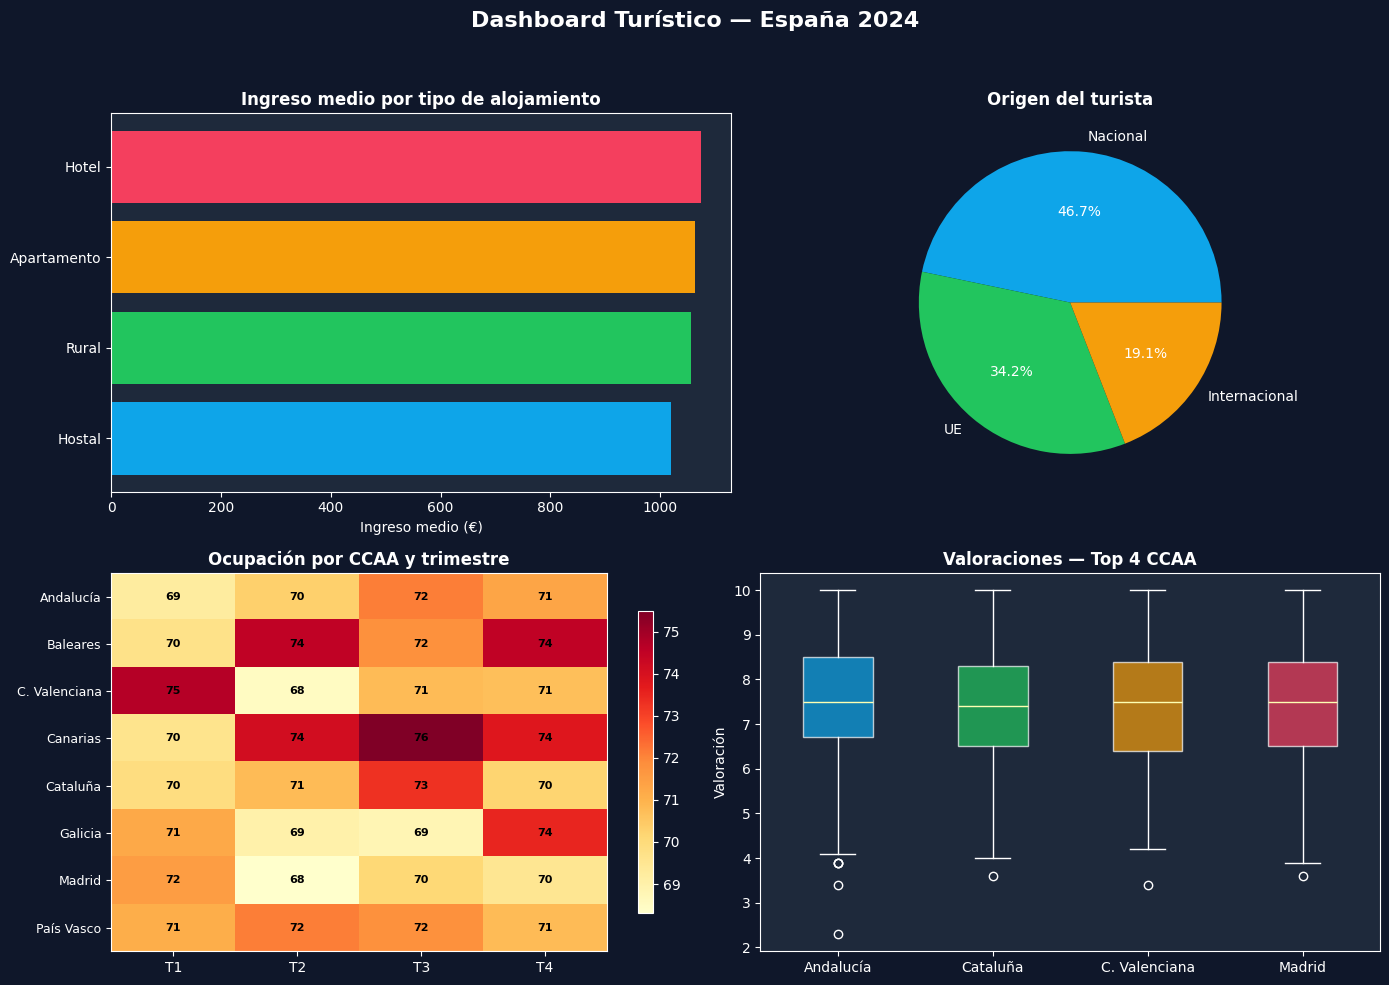

In [27]:
# EJERCICIO 8: Dashboard final 2x2
# Crea un dashboard profesional para el informe ejecutivo

# Preparar datos necesarios
top4 = reservas['comunidad'].value_counts().head(4).index.tolist()
pivot_ocup = pd.pivot_table(reservas, values='ocupacion_pct',
    index='comunidad', columns='trimestre', aggfunc='mean').round(1)

# 1. Crear cuadrícula 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0f172a')
colores_tipo = ['#0ea5e9', '#22c55e', '#f59e0b', '#f43f5e']

# 2. Subplot [0,0]: Barras horizontales — ingreso medio por tipo
ingreso_medio_por_tipo = reservas.groupby('tipo_alojamiento')['ingreso_total'].mean().sort_values()
axes[0, 0].barh(ingreso_medio_por_tipo.index, ingreso_medio_por_tipo.values, color=colores_tipo)
axes[0, 0].set_title('Ingreso medio por tipo de alojamiento', fontweight='bold', color='white')
axes[0, 0].set_xlabel('Ingreso medio (€)', color='white')
axes[0, 0].set_facecolor('#1e293b')
axes[0, 0].tick_params(colors='white')

# 3. Subplot [0,1]: Pie — proporción por origen del turista
origen_counts = reservas['origen_turista'].value_counts()
axes[0, 1].pie(origen_counts, labels=origen_counts.index, autopct='%1.1f%%',
               colors=['#0ea5e9', '#22c55e', '#f59e0b'], textprops={'color': 'white'})
axes[0, 1].set_title('Origen del turista', fontweight='bold', color='white')
axes[0, 1].set_facecolor('#1e293b')

# 4. Subplot [1,0]: Heatmap — ocupación por CCAA y trimestre
im = axes[1, 0].imshow(pivot_ocup.values, cmap='YlOrRd', aspect='auto')
axes[1, 0].set_xticks(range(4))
axes[1, 0].set_xticklabels(['T1', 'T2', 'T3', 'T4'], color='white')
axes[1, 0].set_yticks(range(len(pivot_ocup)))
axes[1, 0].set_yticklabels(pivot_ocup.index, color='white', fontsize=9)
axes[1, 0].set_title('Ocupación por CCAA y trimestre', fontweight='bold', color='white')
axes[1, 0].set_facecolor('#1e293b')
fig.colorbar(im, ax=axes[1, 0], shrink=0.8)

for i in range(len(pivot_ocup)):
    for j in range(4):
        axes[1, 0].text(j, i, f'{pivot_ocup.values[i, j]:.0f}',
                        ha='center', va='center', fontsize=8, color='black', fontweight='bold')

# 5. Subplot [1,1]: Boxplot — valoraciones top 4 CCAA
top4_data = [reservas[reservas['comunidad'] == c]['valoracion'].values for c in top4]
bp = axes[1, 1].boxplot(top4_data, labels=top4, patch_artist=True)
for patch, color in zip(bp['boxes'], colores_tipo):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_title('Valoraciones — Top 4 CCAA', fontweight='bold', color='white')
axes[1, 1].set_ylabel('Valoración', color='white')
axes[1, 1].set_facecolor('#1e293b')
axes[1, 1].tick_params(colors='white')

# 6. Título general y tight_layout
# 6. Título general
fig.suptitle('Dashboard Turístico — España 2024', fontsize=16, fontweight='bold', color='white', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


<details>
<summary><strong>Solucion (click para ver)</strong></summary>

```python
# EJERCICIO 8: Dashboard final 2x2

# Preparar datos
top4 = reservas['comunidad'].value_counts().head(4).index.tolist()
pivot_ocup = pd.pivot_table(reservas, values='ocupacion_pct',
    index='comunidad', columns='trimestre', aggfunc='mean').round(1)

# 1. Cuadrícula
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0f172a')
colores_tipo = ['#0ea5e9', '#22c55e', '#f59e0b', '#f43f5e']

# 2. Barras horizontales
ingreso_tipo = reservas.groupby('tipo_alojamiento')['ingreso_total'].mean().sort_values()
axes[0, 0].barh(ingreso_tipo.index, ingreso_tipo.values, color=colores_tipo)
axes[0, 0].set_title('Ingreso medio por tipo de alojamiento', fontweight='bold', color='white')
axes[0, 0].set_xlabel('Ingreso medio (€)', color='white')
axes[0, 0].set_facecolor('#1e293b')
axes[0, 0].tick_params(colors='white')

# 3. Pie — origen del turista
origen_counts = reservas['origen_turista'].value_counts()
axes[0, 1].pie(origen_counts, labels=origen_counts.index, autopct='%1.1f%%',
               colors=['#0ea5e9', '#22c55e', '#f59e0b'], textprops={'color': 'white'})
axes[0, 1].set_title('Origen del turista', fontweight='bold', color='white')
axes[0, 1].set_facecolor('#1e293b')

# 4. Heatmap — ocupación
im = axes[1, 0].imshow(pivot_ocup.values, cmap='YlOrRd', aspect='auto')
axes[1, 0].set_xticks(range(4))
axes[1, 0].set_xticklabels(['T1', 'T2', 'T3', 'T4'], color='white')
axes[1, 0].set_yticks(range(len(pivot_ocup)))
axes[1, 0].set_yticklabels(pivot_ocup.index, color='white', fontsize=9)
axes[1, 0].set_title('Ocupación por CCAA y trimestre', fontweight='bold', color='white')
axes[1, 0].set_facecolor('#1e293b')
fig.colorbar(im, ax=axes[1, 0], shrink=0.8)

for i in range(len(pivot_ocup)):
    for j in range(4):
        axes[1, 0].text(j, i, f'{pivot_ocup.values[i, j]:.0f}',
                        ha='center', va='center', fontsize=8, color='black', fontweight='bold')

# 5. Boxplot — valoraciones
top4_data = [reservas[reservas['comunidad'] == c]['valoracion'].values for c in top4]
bp = axes[1, 1].boxplot(top4_data, labels=top4, patch_artist=True)
for patch, color in zip(bp['boxes'], colores_tipo):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_title('Valoraciones — Top 4 CCAA', fontweight='bold', color='white')
axes[1, 1].set_ylabel('Valoración', color='white')
axes[1, 1].set_facecolor('#1e293b')
axes[1, 1].tick_params(colors='white')

# 6. Título general
fig.suptitle('Dashboard Turístico — España 2024', fontsize=16, fontweight='bold', color='white', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])

```

</details>
